In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving placement_predict_50k Dataset (1).csv to placement_predict_50k Dataset (1).csv


In [ ]:
df = pd.read_csv("/content/placement_predict_50k Dataset (1).csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset Shape: (50000, 32)

Columns:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [ ]:
TARGET = "Salary Package"

FEATURES = [col for col in df.columns if col != TARGET]

data = df[FEATURES + [TARGET]].copy()

print("Target Column:", TARGET)
print("Number of Features:", len(FEATURES))

Target Column: Salary Package
Number of Features: 31


In [ ]:
numerical_features = data[FEATURES].select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = data[FEATURES].select_dtypes(
    include="object"
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'PlacementStatus', 'IsAnomaly']

Categorical Features:
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA_Tier']


In [ ]:
# Numerical columns → fill missing values with median
for col in numerical_features:
    if data[col].isnull().any():
        data[col] = data[col].fillna(data[col].median())

# Categorical columns → fill missing values with mode
for col in categorical_features:
    if data[col].isnull().any():
        data[col] = data[col].fillna(data[col].mode()[0])

print("Missing values handled successfully.")

Missing values handled successfully.


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [ ]:
X = data[FEATURES]

y = data[TARGET].values.reshape(-1, 1)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (50000, 31)
y Shape: (50000, 1)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (40000, 31)
Testing Data: (10000, 31)


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrix to dense NumPy array
if isinstance(X_train_processed, np.ndarray):
    X_train_s = X_train_processed
    X_test_s = X_test_processed
else:
    X_train_s = X_train_processed.toarray()
    X_test_s = X_test_processed.toarray()

print("Processed Training Shape:", X_train_s.shape)
print("Processed Testing Shape:", X_test_s.shape)

Processed Training Shape: (40000, 55)
Processed Testing Shape: (10000, 55)


In [ ]:
n_samples, n_features = X_train_s.shape

X_train_b = np.hstack([
    np.ones((n_samples, 1)),
    X_train_s
])

X_test_b = np.hstack([
    np.ones((X_test_s.shape[0], 1)),
    X_test_s
])

print("Training Matrix with Bias:", X_train_b.shape)
print("Testing Matrix with Bias:", X_test_b.shape)

Training Matrix with Bias: (40000, 56)
Testing Matrix with Bias: (10000, 56)


In [ ]:
def compute_mse(X, y, theta):
    predictions = X @ theta
    errors = predictions - y

    return np.mean(errors ** 2)

In [ ]:
def batch_gradient_descent(
    X,
    y,
    lr=0.01,
    n_epochs=1000
):
    m, n = X.shape

    theta = np.zeros((n, 1))

    loss_history = []

    for epoch in range(n_epochs):

        predictions = X @ theta

        errors = predictions - y

        gradient = (2 / m) * (X.T @ errors)

        theta -= lr * gradient

        loss_history.append(
            compute_mse(X, y, theta)
        )

    return theta, loss_history

In [ ]:
theta_gd, loss_history_gd = batch_gradient_descent(
    X_train_b,
    y_train,
    lr=0.01,
    n_epochs=1000
)

print("Batch Gradient Descent training completed.")

Batch Gradient Descent training completed.


In [ ]:
rmse_gd = np.sqrt(
    compute_mse(
        X_test_b,
        y_test,
        theta_gd
    )
)

print(
    f"[Batch GD] Test RMSE = {rmse_gd:.4f}"
)

[Batch GD] Test RMSE = 2.0601


In [ ]:
sk_model = LinearRegression()

sk_model.fit(
    X_train_s,
    y_train
)

y_pred_sk = sk_model.predict(
    X_test_s
)

rmse_sklearn = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_sk
    )
)

print(
    f"[sklearn] Test RMSE = {rmse_sklearn:.4f}"
)

[sklearn] Test RMSE = 1.9261


In [ ]:
def mini_batch_gradient_descent(
    X,
    y,
    lr=0.01,
    n_epochs=1000,
    batch_size=256,
    seed=42
):

    m, n = X.shape

    theta = np.zeros((n, 1))

    loss_history = []

    rng = np.random.default_rng(seed)

    for epoch in range(n_epochs):

        indices = rng.permutation(m)

        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for start in range(
            0,
            m,
            batch_size
        ):

            end = start + batch_size

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            predictions = X_batch @ theta

            errors = predictions - y_batch

            gradient = (
                2 / X_batch.shape[0]
            ) * (
                X_batch.T @ errors
            )

            theta -= lr * gradient

        loss_history.append(
            compute_mse(
                X,
                y,
                theta
            )
        )

    return theta, loss_history

In [ ]:
theta_mb, loss_history_mb = mini_batch_gradient_descent(
    X_train_b,
    y_train,
    lr=0.01,
    n_epochs=1000,
    batch_size=256
)

print("Mini-batch Gradient Descent training completed.")

Mini-batch Gradient Descent training completed.


In [ ]:
rmse_mb = np.sqrt(
    compute_mse(
        X_test_b,
        y_test,
        theta_mb
    )
)

print(
    f"[Mini-batch GD] Test RMSE = {rmse_mb:.4f}"
)

[Mini-batch GD] Test RMSE = 1.9281


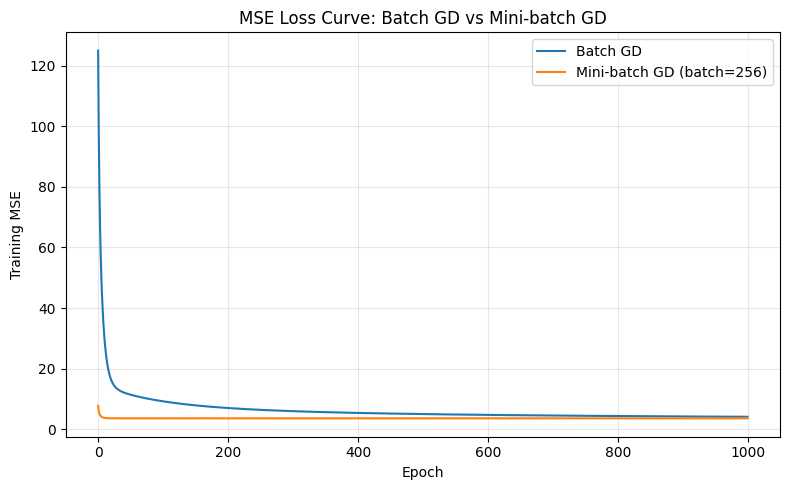

Saved loss curve to loss_curve.png


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    loss_history_gd,
    label="Batch GD"
)

plt.plot(
    loss_history_mb,
    label="Mini-batch GD (batch=256)"
)

plt.xlabel("Epoch")
plt.ylabel("Training MSE")

plt.title(
    "MSE Loss Curve: Batch GD vs Mini-batch GD"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "loss_curve.png",
    dpi=150
)

plt.show()

print("Saved loss curve to loss_curve.png")

In [ ]:
print("\n========== RMSE Comparison ==========")

print(
    f"{'Method':<20}{'Test RMSE':>12}"
)

print(
    f"{'Batch GD':<20}{rmse_gd:>12.4f}"
)

print(
    f"{'Mini-batch GD':<20}{rmse_mb:>12.4f}"
)

print(
    f"{'sklearn LinearReg':<20}{rmse_sklearn:>12.4f}"
)


========== RMSE Comparison ==========
Method                 Test RMSE
Batch GD                  2.0601
Mini-batch GD             1.9281
sklearn LinearReg         1.9261
